# find better representation of methylation by calculating and normalizingmethylation via clusters not cells

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [52]:
# mcds_path = '/ceph/MethDev/pbio/kay/data/Arab10_All_mcds.mcds'
mcds_path = '/ceph/MethDev/pbio/All_mcds.mcds'
rna_path = '/ceph/MethDev/pbio/Arab6_RNA_normalized_data.csv'
meta_path ='/ceph/MethDev/pbio/data/Arab6_cells_and_clusters.csv'

In [12]:
mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna_matrix = pd.read_csv(rna_path,index_col = 0).T
meta = pd.read_csv(meta_path)

In [13]:
#re-format and combine clusters
meta['Cell'] = meta['Cell'].str.replace('.','-')
meta = meta.set_index('Cell')
# meta['Cluster'] = meta['Cluster'].replace({6:1,0:1,4:1,5:3})

In [246]:
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980,cluster
NJ_221007_P1-2-K15-J3,0,0,0,44,0,69,0,0,0,0,...,20,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-E16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12
NJ_221007_P1-2-K15-C15,0,0,0,3,0,110,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P1-2-K15-J4,0,78,0,623,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-M16,0,3,0,36,0,28,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
NJ_221007_P8-5-G10-N21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [247]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

In [248]:
mCGN_mc

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ATCG01220,ATCG01230,ATCG01240,ATCG01250,ATCG01260,ATCG01270,ATCG01280,ATCG01290,ATCG01300,ATCG01310
cell,,,,,,,,,,,,,,,,,,,,,
NJ_221007_P1-2-K15-I15,4,0,0,0,111,0,0,5,0,14,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P1-2-K15-A3,2,5,0,0,111,0,2,3,0,6,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P1-2-K15-I16,1,0,0,0,98,1,2,7,0,23,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P1-2-K15-I3,0,0,0,0,60,0,0,6,0,0,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P1-2-K15-D3,3,0,0,0,64,0,0,2,0,7,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-B9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P8-5-G10-I10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [249]:
filtered_columns = [col for col in mCGN_mc.columns if 'ATM' not in col and 'ATC' not in col and 'cluster' not in col]
mCGN_mc['cluster'] = meta['Cluster']
mCGN_mc_by_cluster = mCGN_mc.groupby('cluster').sum()[filtered_columns]
mCGN_mc_by_cluster
mCGN_cov['cluster'] = meta['Cluster']
mCGN_cov_by_cluster_initial = mCGN_cov.groupby('cluster').sum()[filtered_columns]

In [250]:
# Assuming 'mCGN_cov_by_cluster' is your DataFrame
# Step 1: Calculate the sum of each column
column_sums = mCGN_cov_by_cluster_initial.sum(axis=0)

# Step 2: Create a Boolean mask for columns with sums greater than 10,000
columns_to_keep = column_sums > 10000

# Step 3: Apply the mask to filter the DataFrame
mCGN_cov_by_cluster = mCGN_cov_by_cluster_initial.loc[:, columns_to_keep]

print(f'Filtered DataFrame shape: {mCGN_cov_by_cluster.shape}')


Filtered DataFrame shape: (15, 26355)


In [278]:
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980,cluster
NJ_221007_P1-2-K15-J3,0,0,0,44,0,69,0,0,0,0,...,20,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-E16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12
NJ_221007_P1-2-K15-C15,0,0,0,3,0,110,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P1-2-K15-J4,0,78,0,623,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-M16,0,3,0,36,0,28,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
NJ_221007_P8-5-G10-N21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [279]:
rna_matrix['cluster'] = meta['Cluster']
rna_matrix_by_cluster_initial = rna_matrix.groupby('cluster').median()[filtered_columns]
rna_matrix_by_cluster_initial

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.5,0.0,139.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [280]:
# Assuming 'mCGN_cov_by_cluster' is your DataFrame
# Step 1: Calculate the sum of each column
RNA_column_sums = rna_matrix_by_cluster_initial.sum(axis=0)

# Step 2: Create a Boolean mask for columns with sums greater than 10,000
RNA_columns_to_keep = RNA_column_sums > 0

# Step 3: Apply the mask to filter the DataFrame
rna_matrix_by_cluster = rna_matrix_by_cluster_initial.loc[:, RNA_columns_to_keep]

print(f'Filtered DataFrame shape: {rna_matrix_by_cluster.shape}')

Filtered DataFrame shape: (15, 2805)


In [253]:
mCGN_mc_by_cluster

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,229,215,0,49,15515,166,180,531,8,1201,...,630,29,14,1444,49,0,964,27,5,7
1.0,293,214,2,77,18979,169,196,619,5,1455,...,808,20,19,1779,66,0,1130,38,9,7
2.0,74,51,1,13,4548,67,41,156,2,361,...,156,4,9,382,13,0,263,10,4,2
3.0,153,85,0,30,8491,112,92,270,1,713,...,386,17,9,635,23,0,543,9,7,7
4.0,91,80,0,19,6228,73,56,212,3,579,...,281,16,3,506,24,0,329,6,1,10
5.0,58,63,0,8,5161,59,53,157,1,495,...,240,8,3,492,5,0,322,10,5,7
6.0,89,56,0,7,4711,51,54,147,0,435,...,138,10,7,369,4,2,252,1,1,0
7.0,42,46,0,13,3870,53,44,115,1,295,...,177,9,4,256,6,0,193,4,2,0
8.0,68,35,0,8,2863,19,18,96,2,227,...,96,3,3,238,8,0,178,5,0,1


In [254]:
mCGN_cov_by_cluster

gene,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G03993,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G67550,AT5G67560,AT5G67570,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G67630,AT5G67640
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,8984,3106,10005,25964,2409,3971,10090,5657,7363,7068,...,10937,8023,14421,6485,5780,3606,9841,7305,12175,5021
1.0,10106,3729,11889,31474,2775,4723,12665,6688,9354,9020,...,13872,9891,17302,7967,6742,4400,11583,9302,15791,6279
2.0,2295,870,2650,7316,728,1186,3004,1440,2314,2072,...,3026,2390,3728,1810,1705,978,2560,1777,3279,1545
3.0,4435,1769,5345,13807,1339,2060,5540,3088,3917,3715,...,6130,4536,7521,3507,2961,1779,5032,3701,6989,2808
4.0,3511,1245,3959,10303,1174,1621,4284,2298,3329,3033,...,4660,3400,5749,2686,2588,1513,4180,3242,4734,2205
5.0,2706,1120,3022,8499,870,1279,3650,1960,2290,2225,...,3802,2941,4363,2278,1935,1258,3535,2122,3880,1799
6.0,2489,941,2504,7685,782,1087,3479,1594,2177,2143,...,3234,2190,3299,1707,1252,998,2717,1856,3348,1380
7.0,1604,746,2479,5969,510,952,2375,1387,1673,1658,...,2339,1777,2650,1314,1203,628,1988,1489,2615,1188
8.0,1590,549,1631,4522,393,629,1919,1038,1264,1099,...,1887,1516,2359,1068,950,549,1753,1409,2094,913


In [255]:
# mCGN_mc_t.apply(lambda x:x.var(axis = 0))

In [256]:
mc_mean = mCGN_mc_by_cluster.apply(np.mean, axis=1)
mc_var = mCGN_mc_by_cluster.apply(np.var, axis = 1)
# m = mCGN_mc['mean']
# v = mCGN_mc['var']

In [257]:
mc_mean
# sns.histplot(v,alpha = 0.7)

cluster
0.0     1197.810465
1.0     1413.300172
2.0      352.046639
3.0      661.544181
4.0      514.652329
5.0      408.305948
6.0      355.663881
7.0      264.079698
8.0      213.163635
9.0       31.819129
10.0     100.145139
11.0     156.036961
12.0      62.716081
13.0      90.024948
14.0      32.954252
dtype: float64

In [258]:
mc_var

cluster
0.0     1.622254e+07
1.0     2.115733e+07
2.0     1.668791e+06
3.0     5.415619e+06
4.0     3.785156e+06
5.0     2.173317e+06
6.0     1.672158e+06
7.0     7.836451e+05
8.0     5.465177e+05
9.0     1.866674e+04
10.0    1.294680e+05
11.0    2.527282e+05
12.0    4.761781e+04
13.0    7.526478e+04
14.0    1.179881e+04
dtype: float64

In [259]:
def alpha(m,v):
    return m * (m * (1 - m)/ v - 1)
def beta(m,v):
    return (1-m)*(m*(1-m)/v-1)

In [260]:
a = alpha(mc_mean,mc_var)
a

cluster
0.0    -1303.658462
1.0    -1546.632352
2.0     -378.117967
3.0     -714.923306
4.0     -550.595245
5.0     -439.550125
6.0     -382.493784
7.0     -287.491666
8.0     -230.803407
9.0      -33.490714
10.0    -107.825274
11.0    -170.973039
12.0     -67.813927
13.0     -99.611130
14.0     -35.895377
dtype: float64

In [261]:
b = beta(mc_mean,mc_var)
b

cluster
0.0     1302.570094
1.0     1545.538011
2.0      377.043910
3.0      713.842618
4.0      549.525406
5.0      438.473604
6.0      381.418348
7.0      286.403011
8.0      229.720655
9.0       32.438180
10.0     106.748584
11.0     169.877318
12.0      66.732642
13.0      98.504647
14.0      34.806129
dtype: float64

In [262]:
numerator = mCGN_mc_by_cluster.add(a, axis = 0)
numerator.head()

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,-1074.658462,-1088.658462,-1303.658462,-1254.658462,14211.341538,-1137.658462,-1123.658462,-772.658462,-1295.658462,-102.658462,...,-673.658462,-1274.658462,-1289.658462,140.341538,-1254.658462,-1303.658462,-339.658462,-1276.658462,-1298.658462,-1296.658462
1.0,-1253.632352,-1332.632352,-1544.632352,-1469.632352,17432.367648,-1377.632352,-1350.632352,-927.632352,-1541.632352,-91.632352,...,-738.632352,-1526.632352,-1527.632352,232.367648,-1480.632352,-1546.632352,-416.632352,-1508.632352,-1537.632352,-1539.632352
2.0,-304.117967,-327.117967,-377.117967,-365.117967,4169.882033,-311.117967,-337.117967,-222.117967,-376.117967,-17.117967,...,-222.117967,-374.117967,-369.117967,3.882033,-365.117967,-378.117967,-115.117967,-368.117967,-374.117967,-376.117967
3.0,-561.923306,-629.923306,-714.923306,-684.923306,7776.076694,-602.923306,-622.923306,-444.923306,-713.923306,-1.923306,...,-328.923306,-697.923306,-705.923306,-79.923306,-691.923306,-714.923306,-171.923306,-705.923306,-707.923306,-707.923306
4.0,-459.595245,-470.595245,-550.595245,-531.595245,5677.404755,-477.595245,-494.595245,-338.595245,-547.595245,28.404755,...,-269.595245,-534.595245,-547.595245,-44.595245,-526.595245,-550.595245,-221.595245,-544.595245,-549.595245,-540.595245


In [263]:
denominator = mCGN_cov_by_cluster.add(a, axis=0).add(b, axis = 0)
denominator.head()

gene,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G03993,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G67550,AT5G67560,AT5G67570,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G67630,AT5G67640
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,8982.911632,3104.911632,10003.911632,25962.911632,2407.911632,3969.911632,10088.911632,5655.911632,7361.911632,7066.911632,...,10935.911632,8021.911632,14419.911632,6483.911632,5778.911632,3604.911632,9839.911632,7303.911632,12173.911632,5019.911632
1.0,10104.905659,3727.905659,11887.905659,31472.905659,2773.905659,4721.905659,12663.905659,6686.905659,9352.905659,9018.905659,...,13870.905659,9889.905659,17300.905659,7965.905659,6740.905659,4398.905659,11581.905659,9300.905659,15789.905659,6277.905659
2.0,2293.925944,868.925944,2648.925944,7314.925944,726.925944,1184.925944,3002.925944,1438.925944,2312.925944,2070.925944,...,3024.925944,2388.925944,3726.925944,1808.925944,1703.925944,976.925944,2558.925944,1775.925944,3277.925944,1543.925944
3.0,4433.919311,1767.919311,5343.919311,13805.919311,1337.919311,2058.919311,5538.919311,3086.919311,3915.919311,3713.919311,...,6128.919311,4534.919311,7519.919311,3505.919311,2959.919311,1777.919311,5030.919311,3699.919311,6987.919311,2806.919311
4.0,3509.930161,1243.930161,3957.930161,10301.930161,1172.930161,1619.930161,4282.930161,2296.930161,3327.930161,3031.930161,...,4658.930161,3398.930161,5747.930161,2684.930161,2586.930161,1511.930161,4178.930161,3240.930161,4732.930161,2203.930161


In [264]:
mc_posterior = numerator.div(denominator)
mc_posterior

gene,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G67550,AT5G67560,AT5G67570,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G67630,AT5G67640
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,-0.119634,-0.350625,-0.125417,0.547371,NaN,-0.194629,-0.010175,-0.226251,-0.171105,-0.160559,...,-0.114728,-0.157152,0.136224,-0.103897,-0.220571,-0.357750,0.014262,-0.171779,-0.027901,-0.254319
1.0,-0.124062,-0.357475,-0.123624,0.553885,NaN,-0.196453,-0.007236,-0.225161,-0.159376,-0.151862,...,-0.106672,-0.149813,0.131402,-0.092724,-0.226473,-0.347276,0.020063,-0.159192,-0.026386,-0.240308
2.0,-0.132575,-0.376462,-0.137836,0.570051,NaN,-0.187453,-0.005700,-0.259998,-0.157427,-0.151680,...,-0.120042,-0.152838,0.118565,-0.122790,-0.219562,-0.377836,0.001517,-0.205593,-0.035119,-0.238430
3.0,-0.126733,-0.356308,-0.128169,0.563242,NaN,-0.216096,-0.000347,-0.223499,-0.172354,-0.167996,...,-0.111916,-0.150592,0.128735,-0.093819,-0.235791,-0.397050,-0.015886,-0.187010,-0.024603,-0.251494
4.0,-0.130941,-0.378313,-0.134311,0.551101,NaN,-0.209018,0.006632,-0.234920,-0.158836,-0.156203,...,-0.111312,-0.158460,0.122201,-0.100411,-0.206652,-0.362183,-0.010671,-0.162483,-0.046820,-0.247102
5.0,-0.141058,-0.336529,-0.142854,0.555600,NaN,-0.221101,0.015196,-0.220300,-0.184606,-0.176512,...,-0.107487,-0.143728,0.144993,-0.087640,-0.223147,-0.347316,0.014842,-0.204887,-0.030305,-0.238915
6.0,-0.117967,-0.347362,-0.150022,0.563320,NaN,-0.216860,0.015097,-0.233843,-0.168431,-0.157099,...,-0.114291,-0.166517,0.098397,-0.143320,-0.297775,-0.376652,-0.004968,-0.204048,-0.038989,-0.276660
7.0,-0.153154,-0.324188,-0.110775,0.600295,NaN,-0.181396,0.003163,-0.202388,-0.165375,-0.151783,...,-0.118264,-0.154564,0.123261,-0.084158,-0.231707,-0.452204,-0.015850,-0.189186,-0.036150,-0.238848
8.0,-0.102462,-0.357359,-0.136696,0.582226,NaN,-0.214683,-0.001983,-0.214871,-0.176420,-0.190181,...,-0.117610,-0.149713,0.126890,-0.126349,-0.240067,-0.415762,0.004108,-0.158250,-0.025230,-0.247614


In [265]:
ls = [col[:3] for col in mc_posterior.columns]
pd.DataFrame(ls)[0].unique()

array(['AT1', 'AT2', 'AT3', 'AT4', 'AT5'], dtype=object)

In [266]:
# grouped_counts = mc_posterior.groupby(ls).size().reset_index(name='Count')

In [267]:
# sns.histplot(a/(a+b))

In [268]:
# mCGN_mc['posterior'] = a+

In [269]:
# mCGN_mc.groupby('cluster').mean()

In [270]:
# for each per cluster data frame calculate the posterior normalized scores by beta-binomial distribution 
def beta_binomial(mc,cov):
    
    def alpha(m,v):
        return m*(m *(1-m)/v-1)
    def beta(m,v):
        return (1-m)*(m*(1-m)/v-1)
        
    mc_mean = mc.apply(np.mean, axis=1)
    mc_var = mc.apply(np.var, axis=1)

    a = alpha(mc_mean,mc_var)
    b = beta(mc_mean, mc_var)

    numerator = mc.add(a, axis=0)
    denominator = cov.add(a, axis=0).add(b, axis=0)
    
    mc_posterior = numerator.div(denominator)
    
    return mc_posterior

In [271]:
post_mc_initial = beta_binomial(mCGN_mc_by_cluster, mCGN_cov_by_cluster)
post_mc_initial

gene,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G67550,AT5G67560,AT5G67570,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G67630,AT5G67640
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,-0.119634,-0.350625,-0.125417,0.547371,NaN,-0.194629,-0.010175,-0.226251,-0.171105,-0.160559,...,-0.114728,-0.157152,0.136224,-0.103897,-0.220571,-0.357750,0.014262,-0.171779,-0.027901,-0.254319
1.0,-0.124062,-0.357475,-0.123624,0.553885,NaN,-0.196453,-0.007236,-0.225161,-0.159376,-0.151862,...,-0.106672,-0.149813,0.131402,-0.092724,-0.226473,-0.347276,0.020063,-0.159192,-0.026386,-0.240308
2.0,-0.132575,-0.376462,-0.137836,0.570051,NaN,-0.187453,-0.005700,-0.259998,-0.157427,-0.151680,...,-0.120042,-0.152838,0.118565,-0.122790,-0.219562,-0.377836,0.001517,-0.205593,-0.035119,-0.238430
3.0,-0.126733,-0.356308,-0.128169,0.563242,NaN,-0.216096,-0.000347,-0.223499,-0.172354,-0.167996,...,-0.111916,-0.150592,0.128735,-0.093819,-0.235791,-0.397050,-0.015886,-0.187010,-0.024603,-0.251494
4.0,-0.130941,-0.378313,-0.134311,0.551101,NaN,-0.209018,0.006632,-0.234920,-0.158836,-0.156203,...,-0.111312,-0.158460,0.122201,-0.100411,-0.206652,-0.362183,-0.010671,-0.162483,-0.046820,-0.247102
5.0,-0.141058,-0.336529,-0.142854,0.555600,NaN,-0.221101,0.015196,-0.220300,-0.184606,-0.176512,...,-0.107487,-0.143728,0.144993,-0.087640,-0.223147,-0.347316,0.014842,-0.204887,-0.030305,-0.238915
6.0,-0.117967,-0.347362,-0.150022,0.563320,NaN,-0.216860,0.015097,-0.233843,-0.168431,-0.157099,...,-0.114291,-0.166517,0.098397,-0.143320,-0.297775,-0.376652,-0.004968,-0.204048,-0.038989,-0.276660
7.0,-0.153154,-0.324188,-0.110775,0.600295,NaN,-0.181396,0.003163,-0.202388,-0.165375,-0.151783,...,-0.118264,-0.154564,0.123261,-0.084158,-0.231707,-0.452204,-0.015850,-0.189186,-0.036150,-0.238848
8.0,-0.102462,-0.357359,-0.136696,0.582226,NaN,-0.214683,-0.001983,-0.214871,-0.176420,-0.190181,...,-0.117610,-0.149713,0.126890,-0.126349,-0.240067,-0.415762,0.004108,-0.158250,-0.025230,-0.247614


In [272]:
# Assuming 'mCGN_cov_by_cluster' is your DataFrame
# Step 1: Calculate the sum of each column
post_mc_column_sums = post_mc_initial.sum(axis=0)

# Step 2: Create a Boolean mask for columns with sums greater than 10,000
post_mc_columns_to_keep = (post_mc_column_sums > -1)

# Step 3: Apply the mask to filter the DataFrame
post_mc = post_mc_initial.loc[:, post_mc_columns_to_keep].dropna(axis = 1, how = 'all')

print(f'Filtered DataFrame shape: {post_mc.shape}')

Filtered DataFrame shape: (15, 11377)


In [273]:
post_mc

gene,AT1G01040,AT1G01060,AT1G01150,AT1G01220,AT1G01260,AT1G01300,AT1G01320,AT1G01340,AT1G01350,AT1G01440,...,AT5G67360,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.547371,-0.010175,-0.057505,0.207711,0.095316,-0.046638,0.345723,0.032187,0.168569,0.244949,...,-0.029774,0.081680,-0.043565,-0.016307,-0.017637,0.179134,0.166877,0.136224,0.014262,-0.027901
1.0,0.553885,-0.007236,-0.063644,0.193920,0.087872,-0.042285,0.344857,0.029077,0.177385,0.257460,...,-0.031906,0.082921,-0.041506,-0.013733,-0.011655,0.162676,0.180690,0.131402,0.020063,-0.026386
2.0,0.570051,-0.005700,-0.041942,0.214330,0.096800,-0.048687,0.352083,0.052237,0.114380,0.241633,...,-0.039209,0.081051,-0.045192,-0.018558,-0.012516,0.202386,0.183204,0.118565,0.001517,-0.035119
3.0,0.563242,-0.000347,-0.074238,0.202210,0.100156,-0.050439,0.357395,0.047027,0.170387,0.245488,...,-0.034617,-0.028598,-0.042477,-0.013019,-0.012668,0.199981,0.126253,0.128735,-0.015886,-0.024603
4.0,0.551101,0.006632,-0.047190,0.219761,0.098725,-0.048425,0.350795,0.041797,0.170770,0.267959,...,-0.032631,0.103752,-0.033977,-0.018733,-0.017065,0.190941,0.179114,0.122201,-0.010671,-0.046820
5.0,0.555600,0.015196,-0.071213,0.218894,0.081096,-0.048274,0.355790,0.026826,0.166116,0.226227,...,-0.030353,0.002206,-0.046856,-0.020549,-0.010975,0.187253,0.153319,0.144993,0.014842,-0.030305
6.0,0.563320,0.015097,-0.044793,0.208610,0.096942,-0.045342,0.354566,0.030075,0.148512,0.259478,...,-0.033544,0.061672,-0.042768,-0.022421,-0.007935,0.182535,0.132253,0.098397,-0.004968,-0.038989
7.0,0.600295,0.003163,-0.068249,0.167740,0.076946,-0.042044,0.359642,0.037253,0.145834,0.242388,...,-0.035959,0.161710,-0.049331,-0.006883,-0.028917,0.220670,0.172876,0.123261,-0.015850,-0.036150
8.0,0.582226,-0.001983,-0.067556,0.225121,0.147386,-0.042344,0.349039,0.027586,0.103447,0.259718,...,-0.030822,0.059044,-0.058347,-0.010259,0.006453,0.205565,0.140861,0.126890,0.004108,-0.025230


In [274]:
# Exclude the 15th row (index 14) from the DataFrame
filtered_mc = post_mc.drop(post_mc.index[9])
#filtered_mc = filtered_mc.drop(post_mc.index[2])
#filtered_mc = filtered_mc.drop(post_mc.index[14])

# Alternatively, using a more general approach:
# filtered_df = post_mc.iloc[lambda x: x.index != 14]


In [277]:
rna_matrix_by_cluster

,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01120,AT1G01140,AT1G01290,AT1G01320,AT1G01470,AT1G01490,...,AT5G66730,AT5G66900,AT5G67030,AT5G67140,AT5G67320,AT5G67330,AT5G67370,AT5G67385,AT5G67420,AT5G67510
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,113.0,0.0,0.0,0.0,678.0,0.0,18.0,...,0.0,0.0,890.0,2.0,0.0,0.0,89.0,20.0,0.0,0.0
1,0.0,3.0,1.5,139.5,0.0,18.0,49.5,1332.0,0.0,249.0,...,9.5,4.5,1364.5,25.0,1.0,4.0,239.5,81.0,2.0,43.5
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,237.5,0.0,0.0,...,0.0,0.0,106.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,3.0,0.0,0.0,0.0,4.0,0.0,2.0,...,1.0,0.0,143.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,542.0,0.0,2.0,...,0.0,0.0,318.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,83.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,4.0,0.0,0.0,1.0,729.0,0.0,2.0,...,0.0,0.0,435.0,0.0,0.0,0.0,82.0,20.0,0.0,22.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,36.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,2.0,0.0,0.0,0.0,153.0,0.0,33.0,...,0.0,0.0,111.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [275]:
# Exclude the 15th row (index 14) from the DataFrame
filtered_rna = rna_matrix_by_cluster.drop(rna_matrix_by_cluster.index[9])
#filtered_rna = filtered_rna.drop(rna_matrix_by_cluster.index[2])
#filtered_rna = filtered_rna.drop(rna_matrix_by_cluster.index[14])

# Alternatively, using a more general approach:
# filtered_df = post_mc.iloc[lambda x: x.index != 14]

filtered_rna

,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01120,AT1G01140,AT1G01290,AT1G01320,AT1G01470,AT1G01490,...,AT5G66730,AT5G66900,AT5G67030,AT5G67140,AT5G67320,AT5G67330,AT5G67370,AT5G67385,AT5G67420,AT5G67510
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,113.0,0.0,0.0,0.0,678.0,0.0,18.0,...,0.0,0.0,890.0,2.0,0.0,0.0,89.0,20.0,0.0,0.0
1,0.0,3.0,1.5,139.5,0.0,18.0,49.5,1332.0,0.0,249.0,...,9.5,4.5,1364.5,25.0,1.0,4.0,239.5,81.0,2.0,43.5
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,237.5,0.0,0.0,...,0.0,0.0,106.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,3.0,0.0,0.0,0.0,4.0,0.0,2.0,...,1.0,0.0,143.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,542.0,0.0,2.0,...,0.0,0.0,318.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,83.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,4.0,0.0,0.0,1.0,729.0,0.0,2.0,...,0.0,0.0,435.0,0.0,0.0,0.0,82.0,20.0,0.0,22.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,36.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,2.0,0.0,0.0,0.0,153.0,0.0,33.0,...,0.0,0.0,111.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [276]:
# rna_matrix_by_cluster

In [221]:
filtered_rna_transformed = np.log2(filtered_rna + 1)

# Show the transformed DataFrame
filtered_rna_transformed

,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01120,AT1G01140,AT1G01290,AT1G01320,AT1G01470,AT1G01490,...,AT5G66730,AT5G66900,AT5G67030,AT5G67140,AT5G67320,AT5G67330,AT5G67370,AT5G67385,AT5G67420,AT5G67510
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,6.832890,0.0,0.000000,0.000000,9.407268,0.00000,4.247928,...,0.000000,0.000000,9.799282,1.584963,0.000000,0.000000,6.491853,4.392317,0.000000,0.000000
1,0.000000,2.000000,1.321928,7.134426,0.0,4.247928,5.658211,10.380461,0.00000,7.965784,...,3.392317,2.459432,10.415214,4.700440,1.000000,2.321928,7.909893,6.357552,1.584963,5.475733
2,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,7.897845,0.00000,0.000000,...,0.000000,0.000000,6.748193,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,2.000000,0.0,0.000000,0.000000,2.321928,0.00000,1.584963,...,1.000000,0.000000,7.169925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.584963
4,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,9.084808,0.00000,1.584963,...,0.000000,0.000000,8.317413,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,6.400879,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,2.321928,0.0,0.000000,1.000000,9.511753,0.00000,1.584963,...,0.000000,0.000000,8.768184,0.000000,0.000000,0.000000,6.375039,4.392317,0.000000,4.523562
7,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.00000,0.000000,...,0.000000,0.000000,5.228819,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,1.584963,0.0,0.000000,0.000000,7.266787,0.00000,5.087463,...,0.000000,0.000000,6.807355,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


In [222]:
# post_mc.to_csv('/ceph/MethDev/pbio/kay/data/posterior_mc.csv')

In [223]:
filtered_mc

gene,AT1G01040,AT1G01060,AT1G01150,AT1G01220,AT1G01260,AT1G01300,AT1G01320,AT1G01340,AT1G01350,AT1G01440,...,AT5G67360,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.547371,-0.010175,-0.057505,0.207711,0.095316,-0.046638,0.345723,0.032187,0.168569,0.244949,...,-0.029774,0.081680,-0.043565,-0.016307,-0.017637,0.179134,0.166877,0.136224,0.014262,-0.027901
1.0,0.553885,-0.007236,-0.063644,0.193920,0.087872,-0.042285,0.344857,0.029077,0.177385,0.257460,...,-0.031906,0.082921,-0.041506,-0.013733,-0.011655,0.162676,0.180690,0.131402,0.020063,-0.026386
2.0,0.570051,-0.005700,-0.041942,0.214330,0.096800,-0.048687,0.352083,0.052237,0.114380,0.241633,...,-0.039209,0.081051,-0.045192,-0.018558,-0.012516,0.202386,0.183204,0.118565,0.001517,-0.035119
3.0,0.563242,-0.000347,-0.074238,0.202210,0.100156,-0.050439,0.357395,0.047027,0.170387,0.245488,...,-0.034617,-0.028598,-0.042477,-0.013019,-0.012668,0.199981,0.126253,0.128735,-0.015886,-0.024603
4.0,0.551101,0.006632,-0.047190,0.219761,0.098725,-0.048425,0.350795,0.041797,0.170770,0.267959,...,-0.032631,0.103752,-0.033977,-0.018733,-0.017065,0.190941,0.179114,0.122201,-0.010671,-0.046820
5.0,0.555600,0.015196,-0.071213,0.218894,0.081096,-0.048274,0.355790,0.026826,0.166116,0.226227,...,-0.030353,0.002206,-0.046856,-0.020549,-0.010975,0.187253,0.153319,0.144993,0.014842,-0.030305
6.0,0.563320,0.015097,-0.044793,0.208610,0.096942,-0.045342,0.354566,0.030075,0.148512,0.259478,...,-0.033544,0.061672,-0.042768,-0.022421,-0.007935,0.182535,0.132253,0.098397,-0.004968,-0.038989
7.0,0.600295,0.003163,-0.068249,0.167740,0.076946,-0.042044,0.359642,0.037253,0.145834,0.242388,...,-0.035959,0.161710,-0.049331,-0.006883,-0.028917,0.220670,0.172876,0.123261,-0.015850,-0.036150
8.0,0.582226,-0.001983,-0.067556,0.225121,0.147386,-0.042344,0.349039,0.027586,0.103447,0.259718,...,-0.030822,0.059044,-0.058347,-0.010259,0.006453,0.205565,0.140861,0.126890,0.004108,-0.025230


In [224]:
filtered_rna_transformed

,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01120,AT1G01140,AT1G01290,AT1G01320,AT1G01470,AT1G01490,...,AT5G66730,AT5G66900,AT5G67030,AT5G67140,AT5G67320,AT5G67330,AT5G67370,AT5G67385,AT5G67420,AT5G67510
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,6.832890,0.0,0.000000,0.000000,9.407268,0.00000,4.247928,...,0.000000,0.000000,9.799282,1.584963,0.000000,0.000000,6.491853,4.392317,0.000000,0.000000
1,0.000000,2.000000,1.321928,7.134426,0.0,4.247928,5.658211,10.380461,0.00000,7.965784,...,3.392317,2.459432,10.415214,4.700440,1.000000,2.321928,7.909893,6.357552,1.584963,5.475733
2,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,7.897845,0.00000,0.000000,...,0.000000,0.000000,6.748193,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,2.000000,0.0,0.000000,0.000000,2.321928,0.00000,1.584963,...,1.000000,0.000000,7.169925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.584963
4,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,9.084808,0.00000,1.584963,...,0.000000,0.000000,8.317413,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,6.400879,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,2.321928,0.0,0.000000,1.000000,9.511753,0.00000,1.584963,...,0.000000,0.000000,8.768184,0.000000,0.000000,0.000000,6.375039,4.392317,0.000000,4.523562
7,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.00000,0.000000,...,0.000000,0.000000,5.228819,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,1.584963,0.0,0.000000,0.000000,7.266787,0.00000,5.087463,...,0.000000,0.000000,6.807355,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


In [283]:
corr = filtered_mc.corrwith(filtered_rna_transformed)
corr.dropna()

AT1G01040   -0.003817
AT1G01060   -0.639828
AT1G01320   -0.344556
AT1G01650   -0.539003
AT1G01790    0.060967
               ...   
AT5G66730   -0.199011
AT5G66900    0.263317
AT5G67030    0.404781
AT5G67320    0.184533
AT5G67385   -0.214465
Length: 1270, dtype: float64

In [284]:
# Create an array of shuffled column indices
column_indices = np.arange(filtered_mc.shape[1])
np.random.shuffle(column_indices)

# Create a new DataFrame with columns shuffled according to the shuffled indices
shuffled_df = filtered_mc.iloc[:, column_indices]

# Assign the shuffled columns back to the original DataFrame's column names
for original, new in zip(filtered_mc.columns, shuffled_df.columns):
    filtered_mc[original] = shuffled_df[new]

filtered_mc


gene,AT1G01040,AT1G01060,AT1G01150,AT1G01220,AT1G01260,AT1G01300,AT1G01320,AT1G01340,AT1G01350,AT1G01440,...,AT5G67360,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.054363,-0.046742,0.276890,0.169606,-0.061043,0.070450,0.048983,0.341777,0.201388,-0.049716,...,0.665162,0.326673,0.043334,-0.050877,-0.038021,0.127579,-0.039220,0.059625,0.039995,0.210997
1.0,0.048373,-0.058387,0.258489,0.166316,-0.052656,0.071094,0.044309,0.351514,0.190158,-0.045792,...,0.648442,0.311526,0.047309,-0.051555,-0.041752,0.126378,-0.039844,0.040332,0.034987,0.217681
2.0,0.038331,-0.057294,0.270030,0.179304,-0.057189,0.066620,0.031858,0.372279,0.206941,-0.048453,...,0.732789,0.340953,0.034835,-0.041494,-0.043675,0.172674,-0.043623,0.045037,0.045888,0.228708
3.0,0.038066,-0.046751,0.261630,0.198297,-0.063601,0.087147,0.048250,0.375432,0.222238,-0.045811,...,0.779964,0.306778,0.066460,-0.057945,-0.039229,0.141125,-0.033565,0.023768,0.047686,0.249715
4.0,0.043302,-0.043533,0.249250,0.189590,-0.038056,0.054737,0.047372,0.372168,0.213634,-0.050689,...,0.757286,0.333784,0.058497,-0.054549,-0.038109,0.108811,-0.037381,0.004278,0.035862,0.218271
5.0,0.009908,-0.025055,0.238245,0.201455,-0.066676,0.109228,0.054474,0.350214,0.169927,-0.052357,...,0.780598,0.323089,0.040833,-0.049508,-0.048698,0.135832,-0.039423,0.043458,0.035198,0.225424
6.0,0.039756,-0.095194,0.276064,0.193083,-0.021354,0.057367,0.060227,0.387941,0.196530,-0.052238,...,0.798027,0.315482,0.055623,-0.066192,-0.036501,0.131141,-0.058000,0.040583,0.050936,0.213501
7.0,0.021554,-0.050334,0.315885,0.183159,-0.045505,0.065275,0.072799,0.372825,0.215623,-0.047289,...,0.756938,0.324160,0.058049,-0.046542,-0.048187,0.125283,-0.043098,0.059834,0.019914,0.213937
8.0,0.069950,-0.063283,0.300964,0.181031,-0.039070,0.065692,0.087439,0.352282,0.211826,-0.054964,...,0.761326,0.330752,0.025012,-0.051449,-0.053111,0.142102,-0.036734,0.100350,0.056204,0.223733


In [301]:
df = filtered_rna_transformed

,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01120,AT1G01140,AT1G01290,AT1G01320,AT1G01470,AT1G01490,...,AT5G66730,AT5G66900,AT5G67030,AT5G67140,AT5G67320,AT5G67330,AT5G67370,AT5G67385,AT5G67420,AT5G67510
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,6.832890,0.0,0.000000,0.000000,9.407268,0.00000,4.247928,...,0.000000,0.000000,9.799282,1.584963,0.000000,0.000000,6.491853,4.392317,0.000000,0.000000
1,0.000000,2.000000,1.321928,7.134426,0.0,4.247928,5.658211,10.380461,0.00000,7.965784,...,3.392317,2.459432,10.415214,4.700440,1.000000,2.321928,7.909893,6.357552,1.584963,5.475733
2,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,7.897845,0.00000,0.000000,...,0.000000,0.000000,6.748193,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,2.000000,0.0,0.000000,0.000000,2.321928,0.00000,1.584963,...,1.000000,0.000000,7.169925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.584963
4,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,9.084808,0.00000,1.584963,...,0.000000,0.000000,8.317413,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,6.400879,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,2.321928,0.0,0.000000,1.000000,9.511753,0.00000,1.584963,...,0.000000,0.000000,8.768184,0.000000,0.000000,0.000000,6.375039,4.392317,0.000000,4.523562
7,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.00000,0.000000,...,0.000000,0.000000,5.228819,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,1.584963,0.0,0.000000,0.000000,7.266787,0.00000,5.087463,...,0.000000,0.000000,6.807355,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


In [311]:

# # To shuffle the DataFrame rows:
# # 1. Shuffle the DataFrame and reset the index to keep track of original rows
shuffled_df = df.sample(frac=1).reset_index()

# # 2. Sort the DataFrame by the original index to retain order but shuffled rows
shuffled_df['cluster'] = shuffled_df['cluster'].sample(frac=1).reset_index(drop=True)

# # 3. Set the index back to the original DataFrame's index
shuffled_df.set_index('cluster', inplace=True)

shuffled_df


,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01120,AT1G01140,AT1G01290,AT1G01320,AT1G01470,AT1G01490,...,AT5G66730,AT5G66900,AT5G67030,AT5G67140,AT5G67320,AT5G67330,AT5G67370,AT5G67385,AT5G67420,AT5G67510
cluster,,,,,,,,,,,,,,,,,,,,,
7,0.000000,0.000000,0.000000,2.000000,0.0,0.000000,0.000000,9.041659,0.00000,4.832890,...,0.000000,0.000000,8.878051,0.000000,0.000000,0.000000,5.169925,2.321928,0.000000,3.807355
2,0.000000,0.000000,0.000000,6.832890,0.0,0.000000,0.000000,9.407268,0.00000,4.247928,...,0.000000,0.000000,9.799282,1.584963,0.000000,0.000000,6.491853,4.392317,0.000000,0.000000
11,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,1.584963,5.97728,0.000000,...,0.000000,0.000000,4.087463,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12,0.000000,0.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,6.400879,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,1.584963,0.0,0.000000,0.000000,7.266787,0.00000,5.087463,...,0.000000,0.000000,6.807355,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
14,0.000000,0.000000,0.000000,2.000000,0.0,0.000000,0.000000,2.321928,0.00000,1.584963,...,1.000000,0.000000,7.169925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.584963
6,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,7.897845,0.00000,0.000000,...,0.000000,0.000000,6.748193,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,2.321928,0.0,0.000000,1.000000,9.511753,0.00000,1.584963,...,0.000000,0.000000,8.768184,0.000000,0.000000,0.000000,6.375039,4.392317,0.000000,4.523562
5,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.00000,0.000000,...,0.000000,0.000000,5.228819,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [312]:
corr_rand= filtered_mc.corrwith(shuffled_df)
corr_rand

AT1G01040   -0.127844
AT1G01060   -0.051502
AT1G01320    0.026843
AT1G01650    0.350996
AT1G01790   -0.002406
               ...   
AT5G67530         NaN
AT5G67540         NaN
AT5G67570         NaN
AT5G67610         NaN
AT5G67630         NaN
Length: 12912, dtype: float64

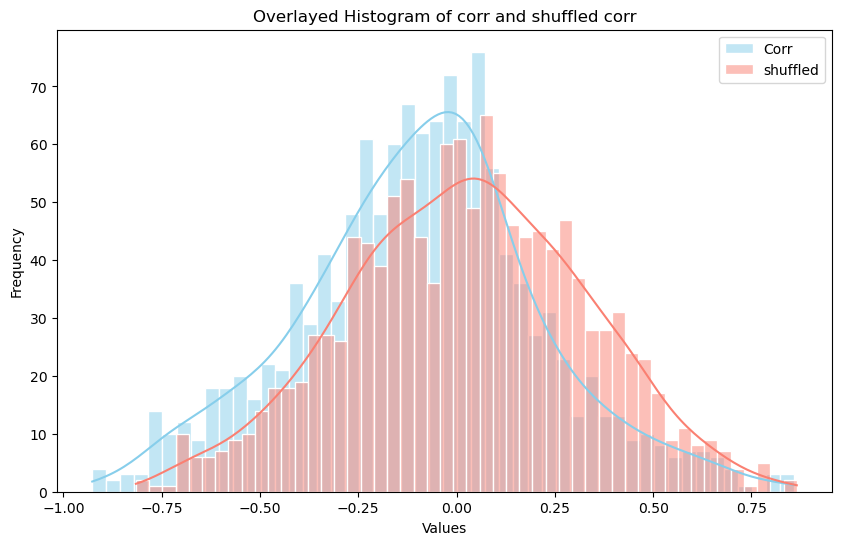

In [316]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming corr and corr_rand are defined and are your actual data
# Example data:
# corr = np.random.normal(loc=0, scale=1, size=100)
# corr_rand = np.random.normal(loc=0, scale=1, size=100)

# Set up the matplotlib figure (optional)
plt.figure(figsize=(10, 6))

# Plotting with more distinct colors and increased transparency
sns.histplot(corr, color='skyblue', kde=True, label='Corr', alpha=0.5, edgecolor='white', bins=50)
sns.histplot(corr_rand, color='salmon', kde=True, label='shuffled', alpha=0.5, edgecolor='white', bins=50)

# Customizing plot
plt.title('Overlayed Histogram of corr and shuffled corr')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.legend()  # Add a legend

# Show the plot
plt.show()


In [229]:
from scipy import stats

# Assume corr and corr_rand are your data samples
# t-test
t_stat, p_value = stats.ttest_ind(corr, corr_rand, equal_var=True)

print(f'T-statistic: {t_stat}')
print(f'p-value: {p_value}')

# Interpret the p-value
if p_value < 0.05: # Assuming a 5% significance level
    print("We reject the null hypothesis. There is a significant difference between the two samples.")
else:
    print("We fail to reject the null hypothesis. There is no significant difference between the two samples.")


T-statistic: nan
p-value: nan
We fail to reject the null hypothesis. There is no significant difference between the two samples.


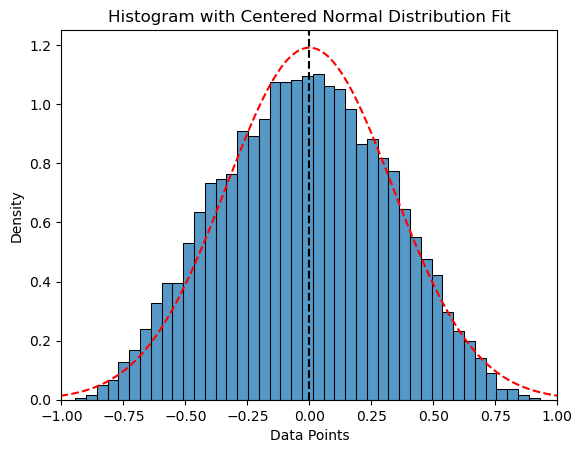

In [86]:

# Assuming 'corr' is your data series
# Fixed mean at 0
data_mean = 0

# Use the standard deviation of your data for a better fit:
data_std = corr.std()

# Generate a normal distribution curve centered at zero
x = np.linspace(-3 * data_std, 3 * data_std, 100)  # Typically, +/- 3 standard deviations
y = norm.pdf(x, data_mean, data_std)  # Probability density function

# Plot the histogram of your data
sns.histplot(corr, kde=False, stat="density")  # 'stat="density"' normalizes the histogram

# Overlay the standard normal distribution curve
plt.plot(x, y, 'r--')  # 'r--' means red dashed line

# Draw a vertical line through zero on the x-axis
plt.axvline(x=0, color='k', linestyle='--')  # 'k' is color black, '--' dashed line

# Set x-axis limits
plt.xlim(-1, 1)

# Optional: Titles and labels
plt.title('Histogram with Centered Normal Distribution Fit')
plt.xlabel('Data Points')
plt.ylabel('Density')

plt.show()


In [358]:
corr.to_csv('/ceph/MethDev/pbio/kay/data/corr_Jimmy.csv')

In [279]:
corr['AT2G10940'], corr['AT4G30400']

(-0.647387290024698, nan)

In [135]:
mCGN_cov_by_cluster['AT2G10940'], mCGN_cov_by_cluster['AT4G30400']

(cluster
 0.0     7961
 1.0     9358
 2.0     2086
 3.0     3889
 4.0     3431
 5.0     2251
 6.0     2125
 7.0     1459
 8.0     1502
 9.0      153
 10.0     613
 11.0     935
 12.0     446
 13.0     701
 14.0     203
 Name: AT2G10940, dtype: int32,
 cluster
 0.0     7383
 1.0     8824
 2.0     2184
 3.0     3932
 4.0     3225
 5.0     2102
 6.0     2209
 7.0     1665
 8.0     1197
 9.0      256
 10.0     485
 11.0    1010
 12.0     393
 13.0     702
 14.0     158
 Name: AT4G30400, dtype: int32)

In [226]:
rna_matrix_by_cluster_transformed['AT2G10940'], rna_matrix_by_cluster_transformed['AT4G30400']

(cluster
 0     6.561478
 1     6.964199
 2     6.190801
 3     4.831922
 4     6.922013
 5     4.506500
 6     7.510390
 7     5.352197
 8     5.174438
 9     3.471935
 10    4.244966
 11    6.516306
 12    2.477322
 13    3.906891
 14    3.636625
 Name: AT2G10940, dtype: float64,
 cluster
 0     1.321421
 1     0.240433
 2     0.045410
 3     5.737080
 4     0.021761
 5     6.295933
 6     1.684679
 7     4.304474
 8     0.032180
 9     1.037868
 10    2.314414
 11    0.089637
 12    0.000000
 13    0.000000
 14    0.000000
 Name: AT4G30400, dtype: float64)

In [156]:
post_mc['AT2G10940'], post_mc['AT4G30400']

(cluster
 0.0    -0.089908
 1.0    -0.110467
 2.0    -0.009170
 3.0     0.414123
 4.0    -0.028746
 5.0     0.487772
 6.0    -0.039782
 7.0     0.420813
 8.0    -0.007864
 9.0     0.121814
 10.0    0.381052
 11.0   -0.037448
 12.0    0.494891
 13.0   -0.099460
 14.0    0.238247
 Name: AT2G10940, dtype: float64,
 cluster
 0.0     0.010613
 1.0     0.013643
 2.0     0.035220
 3.0    -0.142950
 4.0     0.026181
 5.0    -0.186370
 6.0     0.006117
 7.0    -0.048976
 8.0     0.008526
 9.0     0.100057
 10.0   -0.084363
 11.0   -0.014841
 12.0   -0.017386
 13.0    0.076173
 14.0   -0.005706
 Name: AT4G30400, dtype: float64)

In [138]:
#corr of lowest corr score
corr['AT1G14680'], corr['AT4G13720']

(-0.9361769297363765, -0.9353834850735459)

In [139]:
#cov of lowest corr score
mCGN_cov_by_cluster['AT1G14680'], mCGN_cov_by_cluster['AT4G13720']

(cluster
 0.0     7683
 1.0     8178
 2.0     2024
 3.0     3556
 4.0     3099
 5.0     2722
 6.0     2139
 7.0     1596
 8.0     1168
 9.0      321
 10.0     558
 11.0    1043
 12.0     260
 13.0     502
 14.0      69
 Name: AT1G14680, dtype: int32,
 cluster
 0.0     6672
 1.0     7649
 2.0     1569
 3.0     3642
 4.0     2776
 5.0     2126
 6.0     1808
 7.0     1402
 8.0     1018
 9.0      146
 10.0     521
 11.0     888
 12.0     472
 13.0     542
 14.0     175
 Name: AT4G13720, dtype: int32)

In [140]:
#rna score of lowest corr score
rna_matrix_by_cluster['AT1G14680'], rna_matrix_by_cluster['AT4G13720']

(cluster
 0      0.307557
 1      0.341969
 2      0.183140
 3      2.022293
 4      0.021277
 5      2.642857
 6      2.389831
 7      0.000000
 8      1.278195
 9      0.000000
 10     0.012987
 11     0.051282
 12     0.039216
 13     0.000000
 14    34.187500
 Name: AT1G14680, dtype: float64,
 cluster
 0      2.604569
 1      5.121762
 2      0.648256
 3      2.496815
 4      4.285714
 5      3.239796
 6      5.350282
 7      5.240506
 8      1.992481
 9      0.000000
 10     0.207792
 11     4.230769
 12     0.098039
 13     0.080000
 14    36.000000
 Name: AT4G13720, dtype: float64)

In [150]:
#post_mc score of lowest corr score
post_mc['AT1G14680'], post_mc['AT4G13720']

(cluster
 0.0    -0.165670
 1.0    -0.184621
 2.0    -0.183950
 3.0    -0.195201
 4.0    -0.171597
 5.0    -0.157502
 6.0    -0.175635
 7.0    -0.176494
 8.0    -0.193504
 9.0    -0.104676
 10.0   -0.190018
 11.0   -0.158338
 12.0   -0.261912
 13.0   -0.186888
 14.0   -0.528567
 Name: AT1G14680, dtype: float64,
 cluster
 0.0    -0.053765
 1.0    -0.044278
 2.0    -0.060027
 3.0    -0.051614
 4.0    -0.037333
 5.0    -0.049672
 6.0    -0.058936
 7.0    -0.026049
 8.0    -0.041108
 9.0    -0.044780
 10.0   -0.015051
 11.0   -0.058601
 12.0   -0.031458
 13.0   -0.028862
 14.0   -0.177651
 Name: AT4G13720, dtype: float64)

In [230]:
#corr of highest corr score
corr['AT5G64030'], corr['AT5G19320'], corr['AT2G04690']

(2.067652894780747e-06, 1.7394379081163605e-05, 0.8591858221156906)

In [231]:
#cov of highest corr score
mCGN_cov_by_cluster['AT5G64030'], mCGN_cov_by_cluster['AT5G19320'], mCGN_cov_by_cluster['AT2G04690']

(cluster
 0.0     16739
 1.0     19692
 2.0      4571
 3.0      8470
 4.0      6758
 5.0      5328
 6.0      4563
 7.0      3266
 8.0      3053
 9.0       525
 10.0     1273
 11.0     2282
 12.0      831
 13.0     1402
 14.0      452
 Name: AT5G64030, dtype: int32,
 cluster
 0.0     10789
 1.0     13219
 2.0      2777
 3.0      5745
 4.0      4095
 5.0      3384
 6.0      3106
 7.0      1992
 8.0      1885
 9.0       220
 10.0      784
 11.0     1600
 12.0      545
 13.0      786
 14.0      275
 Name: AT5G19320, dtype: int32,
 cluster
 0.0     5400
 1.0     5757
 2.0     1367
 3.0     2818
 4.0     2115
 5.0     1732
 6.0     1288
 7.0     1011
 8.0      873
 9.0      102
 10.0     357
 11.0     654
 12.0     278
 13.0     452
 14.0      98
 Name: AT2G04690, dtype: int32)

In [232]:
#rna score of highest corr score
rna_matrix_by_cluster['AT5G64030'], rna_matrix_by_cluster['AT5G19320'], rna_matrix_by_cluster['AT2G04690']

(cluster
 0     40.435852
 1     84.365285
 2     15.630814
 3     21.684713
 4     28.316109
 5     30.872449
 6     61.807910
 7     51.708861
 8     53.172932
 9      2.680851
 10    28.662338
 11    37.961538
 12    31.509804
 13    19.560000
 14    20.125000
 Name: AT5G64030, dtype: float64,
 cluster
 0      6.402460
 1      3.567358
 2      0.773256
 3      3.095541
 4      2.787234
 5      2.137755
 6      3.435028
 7     10.481013
 8      5.135338
 9      0.000000
 10     3.064935
 11     1.935897
 12    11.274510
 13     0.080000
 14     0.062500
 Name: AT5G19320, dtype: float64,
 cluster
 0     33.543058
 1     68.362694
 2     26.720930
 3     23.958599
 4     47.817629
 5     26.693878
 6     40.355932
 7     23.196203
 8     30.263158
 9      0.265957
 10    26.675325
 11    56.461538
 12    24.960784
 13    79.400000
 14    13.437500
 Name: AT2G04690, dtype: float64)

In [233]:
#post_mc of highest corr score
post_mc['AT5G64030'], post_mc['AT5G19320'], post_mc['AT2G04690']

(cluster
 0.0     0.229918
 1.0     0.240333
 2.0     0.250525
 3.0     0.259310
 4.0     0.257721
 5.0     0.276229
 6.0     0.251540
 7.0     0.269076
 8.0     0.293978
 9.0     0.264357
 10.0    0.299684
 11.0    0.234568
 12.0    0.220728
 13.0    0.201578
 14.0    0.237530
 Name: AT5G64030, dtype: float64,
 cluster
 0.0     0.229455
 1.0     0.223513
 2.0     0.225468
 3.0     0.255066
 4.0     0.246561
 5.0     0.276226
 6.0     0.271667
 7.0     0.231305
 8.0     0.272940
 9.0     0.189586
 10.0    0.262062
 11.0    0.219542
 12.0    0.193386
 13.0    0.260403
 14.0    0.157367
 Name: AT5G19320, dtype: float64,
 cluster
 0.0     0.034144
 1.0     0.005102
 2.0    -0.006675
 3.0     0.040142
 4.0     0.043712
 5.0     0.032035
 6.0    -0.000384
 7.0     0.022287
 8.0     0.027751
 9.0    -0.133641
 10.0    0.000491
 11.0    0.056711
 12.0   -0.010162
 13.0    0.127278
 14.0   -0.091789
 Name: AT2G04690, dtype: float64)

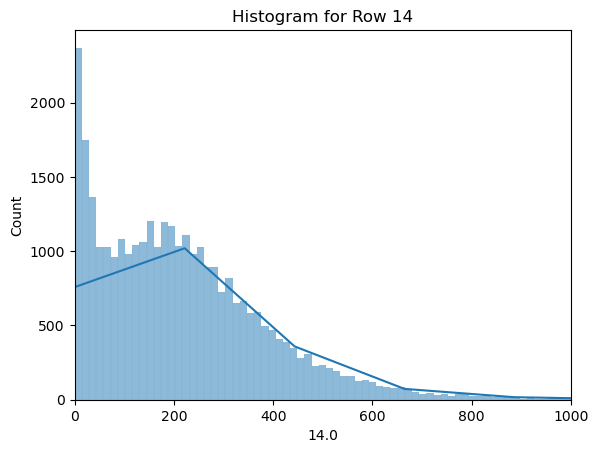

In [50]:
# Assuming 'mCGN_cov_by_cluster' is your DataFrame and you want to plot the first row
row_index = 14
selected_row = mCGN_cov_by_cluster.iloc[row_index]

# Plotting the histogram of the selected row
sns.histplot(selected_row, kde=True)  # 'kde=True' adds a density curve, optional
plt.title(f'Histogram for Row {row_index}')

# Set the y-axis limit to 0.25e6 (which is 250,000)
plt.xlim(0, 0.001e6)

plt.show()


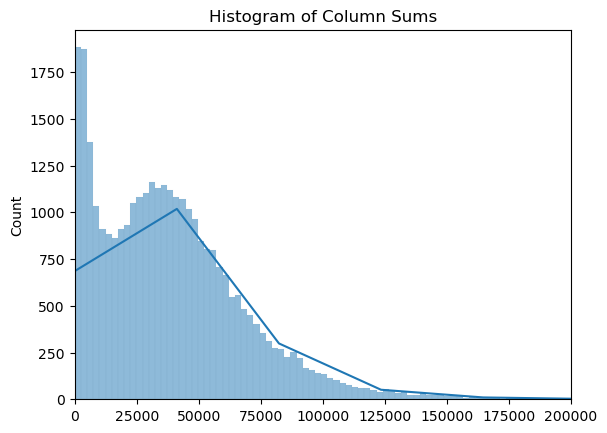

In [66]:
# Assuming 'mCGN_cov_by_cluster' is your DataFrame
# Calculate the sum of each column
column_sums = mCGN_cov_by_cluster.sum(axis=0)

# Plotting the histogram of the sums
sns.histplot(column_sums, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Column Sums')

# Set the x-axis limit if needed (example here sets it for better visualization)
plt.xlim(0, 0.2e6)  # Adjust this limit based on your specific data

plt.show()



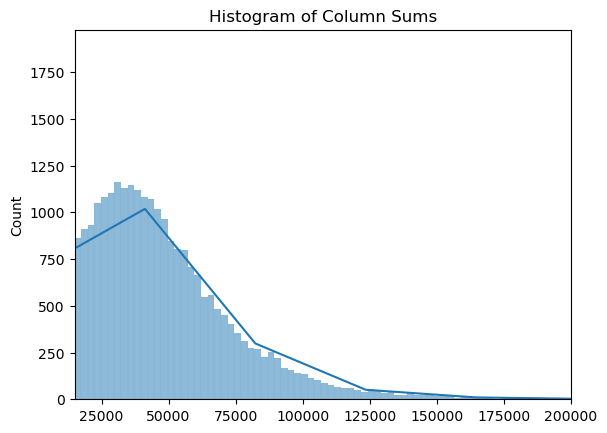

In [67]:
# Assuming 'mCGN_cov_by_cluster' is your DataFrame
# Calculate the sum of each column
column_sums = mCGN_cov_by_cluster.sum(axis=0)

# Plotting the histogram of the sums
sns.histplot(column_sums, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Column Sums')

# Set the x-axis limit if needed (example here sets it for better visualization)
plt.xlim(15000, 0.2e6)  # Adjust this limit based on your specific data

plt.show()



In [68]:
count_columns_above_10000 = (column_sums > 10000).sum()

print(f'Number of columns with a sum above 10,000: {count_columns_above_10000}')



Number of columns with a sum above 10,000: 26355


In [70]:
count_columns_above_0 = (column_sums > 0).sum()

print(f'Number of columns with a sum above 0: {count_columns_above_0}')



Number of columns with a sum above 0: 32208


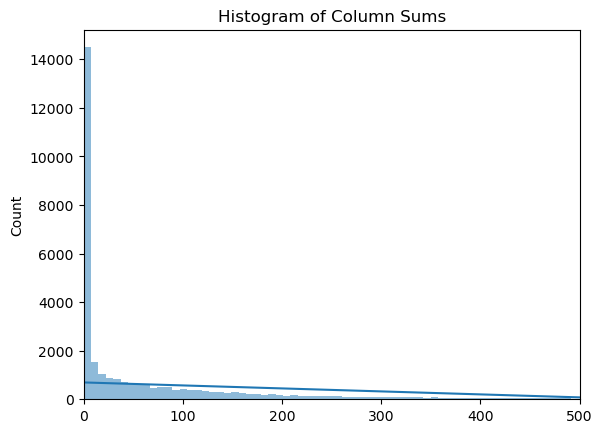

In [71]:
# Assuming 'rna_matrix_by_cluster' is your DataFrame
# Calculate the sum of each column
column_sums = rna_matrix_by_cluster.sum(axis=0)

# Plotting the histogram of the sums
sns.histplot(column_sums, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Column Sums')

# Set the x-axis limit if needed (example here sets it for better visualization)
plt.xlim(0, 500)  # Adjust this limit based on your specific data

plt.show()



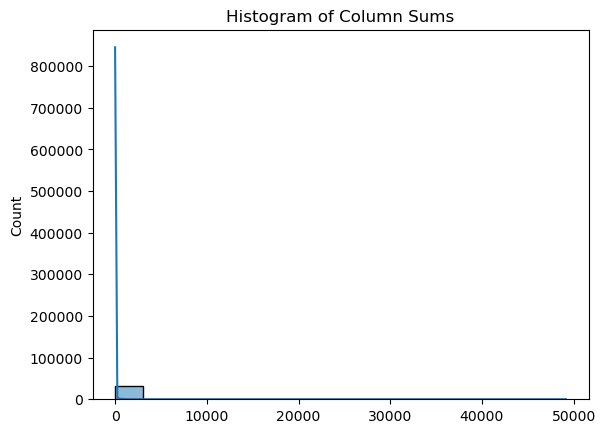

In [240]:
# Assuming 'rna_matrix_by_cluster_initial' is your DataFrame
# Calculate the sum of each column
column_sums = rna_matrix_by_cluster_initial.sum(axis=0)

# Plotting the histogram of the sums
sns.histplot(column_sums, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Column Sums')

# Set the x-axis limit if needed (example here sets it for better visualization)
#plt.xlim(0, 10)  # Adjust this limit based on your specific data

plt.show()



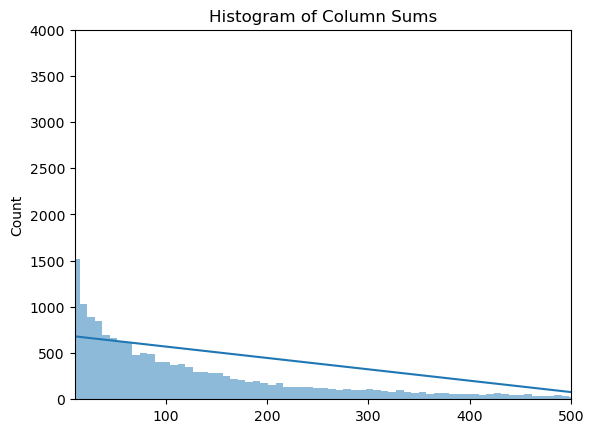

In [72]:
# Assuming 'rna_matrix_by_cluster' is your DataFrame
# Calculate the sum of each column
column_sums = rna_matrix_by_cluster.sum(axis=0)

# Plotting the histogram of the sums
sns.histplot(column_sums, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Column Sums')

# Set the x-axis limit if needed (example here sets it for better visualization)
plt.xlim(10, 500)  # Adjust this limit based on your specific data
plt.ylim(0, 4000)  # Adjust this limit based on your specific data

plt.show()



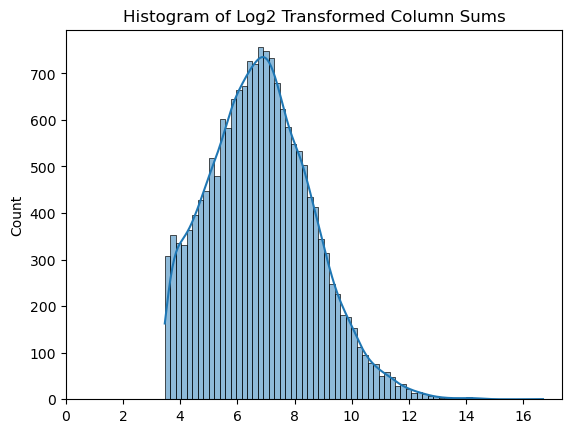

In [219]:
# Assuming 'rna_matrix_by_cluster' is your DataFrame
# Calculate the sum of each column
column_sums = rna_matrix_by_cluster.sum(axis=0)

# Apply log2 transformation to each column sum + 1
log_transformed_sums = np.log2(column_sums + 1)

# Plotting the histogram of the log-transformed sums
sns.histplot(log_transformed_sums, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Log2 Transformed Column Sums')

# Set the x-axis limit if needed (adjust based on the transformed data)
plt.xlim(left=0)  # Set only the lower bound to ensure all data is visible

plt.show()

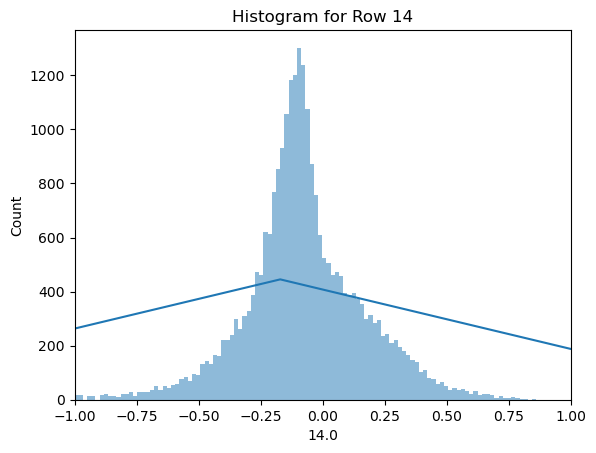

In [155]:
# Assuming 'post_mc' is your DataFrame and you want to plot the first row
row_index = 14
selected_row = post_mc.iloc[row_index]

# Plotting the histogram of the selected row
sns.histplot(selected_row, kde=True)  # 'kde=True' adds a density curve, optional
plt.title(f'Histogram for Row {row_index}')

# Set the y-axis limit to 0.25e6 (which is 250,000)
plt.xlim(-1, 1)

plt.show()

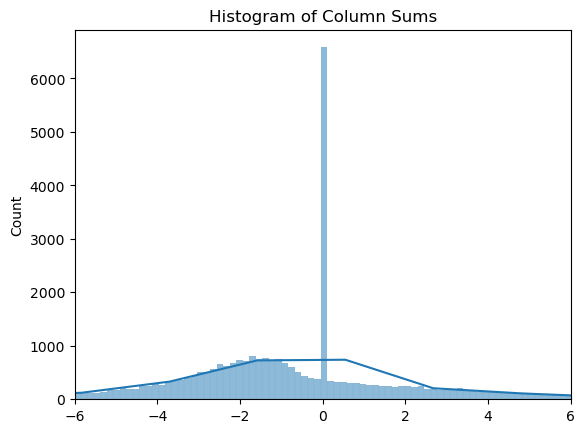

In [160]:
# Assuming 'post_mc' is your DataFrame
# Calculate the sum of each column
column_sums = post_mc.sum(axis=0)

# Plotting the histogram of the sums
sns.histplot(column_sums, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Column Sums')

# Set the x-axis limit if needed (example here sets it for better visualization)
plt.xlim(-6, 6)  # Adjust this limit based on your specific data
#plt.ylim(0, 4000)  # Adjust this limit based on your specific data

plt.show()


In [234]:
# Assuming 'post_mc' is your DataFrame
# Calculate the variance of each column
column_variances = post_mc.var()

# Plotting the histogram of the variances
sns.histplot(column_variances, kde=True)  # 'kde=True' adds a density curve, optional
plt.title('Histogram of Column Variances')

# Set the x-axis limits if needed
plt.xlim(-1, 1)  # Adjust this based on your specific variance data range

plt.show()


KeyboardInterrupt: 

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x148466422280> (for post_execute):



KeyboardInterrupt



Error in callback <function flush_figures at 0x1484664220d0> (for post_execute):



KeyboardInterrupt



In [164]:
count_columns_above_0 = (column_sums > 0).sum()

print(f'Number of columns with a sum above 0: {count_columns_above_0}')



Number of columns with a sum above 0: 8219


In [73]:
count_columns_above_0 = (column_sums > 0).sum()

print(f'Number of columns with a sum above 0: {count_columns_above_0}')




Number of columns with a sum above 0: 29878


In [74]:
count_columns_above_10 = (column_sums > 10).sum()

print(f'Number of columns with a sum above 10: {count_columns_above_10}')




Number of columns with a sum above 10: 17448


In [65]:
m_mc = mCGN_mc.mean(axis=1)
v_mc = mCGN_mc.var(axis=1)
m_mc

cell
NJ_221007_P1-2-K15-I15    6.865079
NJ_221007_P1-2-K15-A3     4.970336
NJ_221007_P1-2-K15-I16    6.652586
NJ_221007_P1-2-K15-I3     4.559055
NJ_221007_P1-2-K15-D3     4.478011
                            ...   
NJ_221007_P8-5-G10-B9     0.057501
NJ_221007_P8-5-G10-O10    0.054212
NJ_221007_P8-5-G10-I10    0.041969
NJ_221007_P8-5-G10-J21    0.037187
NJ_221007_P8-5-G10-G9     0.017299
Length: 3005, dtype: float64

In [68]:
m_cov = mCGN_cov.mean(axis=1)
v_cov = mCGN_cov.var(axis=1)
m_cov

cell
NJ_221007_P1-2-K15-I15    47.419017
NJ_221007_P1-2-K15-A3     37.838552
NJ_221007_P1-2-K15-I16    50.982609
NJ_221007_P1-2-K15-I3     32.963727
NJ_221007_P1-2-K15-D3     34.696930
                            ...    
NJ_221007_P8-5-G10-B9      0.359505
NJ_221007_P8-5-G10-O10     0.355577
NJ_221007_P8-5-G10-I10     0.312115
NJ_221007_P8-5-G10-J21     0.227143
NJ_221007_P8-5-G10-G9      0.103186
Length: 3005, dtype: float64

In [69]:
a_mc = alpha(m_mc, v_mc)
b_mc = beta(m_mc, v_mc)

a_cov = alpha(m_cov, v_cov)
b_cov = beta(m_cov, v_cov)

In [72]:
denominator = a_mc + b_mc + a_cov + b_cov + mCGN_cov

# Perform the scaling operation
normalized_mc = (a_mc + mCGN_mc) / denominator
normalized_cov = (a_cov + mCGN_cov) / denominator

In [74]:
denominator

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,NJ_221007_P8-6-G10-N24,NJ_221007_P8-6-G10-O11,NJ_221007_P8-6-G10-O12,NJ_221007_P8-6-G10-O23,NJ_221007_P8-6-G10-O24,NJ_221007_P8-6-G10-P11,NJ_221007_P8-6-G10-P12,NJ_221007_P8-6-G10-P23,NJ_221007_P8-6-G10-P24,cluster
cell,,,,,,,,,,,,,,,,,,,,,
NJ_221007_P1-2-K15-I15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NJ_221007_P1-2-K15-A3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NJ_221007_P1-2-K15-I16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NJ_221007_P1-2-K15-I3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NJ_221007_P1-2-K15-D3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-B9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NJ_221007_P8-5-G10-O10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NJ_221007_P8-5-G10-I10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
mCGN_frac_by_cluster = mCGN_mc_by_cluster.div(mCGN_cov_by_cluster).fillna(0)
mCGN_frac_by_cluster

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ATCG01220,ATCG01230,ATCG01240,ATCG01250,ATCG01260,ATCG01270,ATCG01280,ATCG01290,ATCG01300,ATCG01310
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.025490,0.069221,0.000000,0.004898,0.597558,0.068908,0.507042,0.133719,0.008969,0.119029,...,0.0,0.038462,0.076923,0.0,0.0,0.0,0.027778,0.0,0.0,0.000000
1.0,0.028993,0.057388,0.009804,0.006477,0.603006,0.060901,0.518519,0.131061,0.004748,0.114884,...,0.0,0.000000,0.068966,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2.0,0.032244,0.058621,0.027027,0.004906,0.621651,0.092033,0.493976,0.131535,0.007092,0.120173,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3.0,0.034498,0.048050,0.000000,0.005613,0.614978,0.083645,0.582278,0.131068,0.002392,0.128700,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
4.0,0.025919,0.064257,0.000000,0.004799,0.604484,0.062181,0.533333,0.130783,0.006623,0.135154,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.011494,0.0,0.0,0.111111
5.0,0.021434,0.056250,0.000000,0.002647,0.607248,0.067816,0.535354,0.122752,0.003425,0.135616,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
6.0,0.035757,0.059511,0.000000,0.002796,0.613012,0.065217,0.514286,0.135235,0.000000,0.125036,...,0.0,0.000000,0.000000,0.0,0.5,0.0,0.000000,0.0,0.0,0.000000
7.0,0.026185,0.061662,0.000000,0.005244,0.648350,0.103922,0.523810,0.120798,0.005102,0.124211,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
8.0,0.042767,0.063752,0.000000,0.004905,0.633127,0.048346,0.339623,0.152623,0.015504,0.118291,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.100000


In [87]:
# #assign cluster to meth data
# mCGN_frac['cluster'] = meta['Cluster']
# #exclude cluster 2/9
# # mCGN_frac = mCGN_frac[~mCGN_frac['cluster'].isin([2])]
# # mCGN_frac = mCGN_frac[~mCGN_frac['cluster'].isin([9])]
# mCGN_frac

In [88]:
# cluster_meth_matrix = mCGN_frac.groupby('cluster').mean().T
# filtered_meth_df = cluster_meth_matrix[cluster_meth_matrix.apply(lambda x: (x >= 0.0).any(), axis=1)]
# filtered_meth_df

In [89]:
# get gene index for methylation values exceeding certain threshold
filtered_index = mCGN_frac_by_cluster.index

In [41]:
#filter cluster information
rna_matrix['cluster'] = meta['Cluster']
#.replace({6:1,0:1,4:1,5:3})
# rna_matrix = rna_matrix[~rna_matrix['cluster'].isin([2])]
rna_matrix
#= rna_matrix.groupby('cluster').mean().T
#cluster_rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980,cluster
NJ_221007_P1-2-K15-J3,0,0,0,44,0,69,0,0,0,0,...,20,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-E16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12
NJ_221007_P1-2-K15-C15,0,0,0,3,0,110,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P1-2-K15-J4,0,78,0,623,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-M16,0,3,0,36,0,28,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
NJ_221007_P8-5-G10-N21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [42]:
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980,cluster
NJ_221007_P1-2-K15-J3,0,0,0,44,0,69,0,0,0,0,...,20,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-E16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12
NJ_221007_P1-2-K15-C15,0,0,0,3,0,110,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P1-2-K15-J4,0,78,0,623,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-M16,0,3,0,36,0,28,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
NJ_221007_P8-5-G10-N21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [43]:
# filtered_rna_df = cluster_rna_matrix.reindex(filtered_index)
# filtered_rna_df

In [91]:
corr_values = mCGN_frac_by_cluster.corrwith(rna_matrix, axis =0)
corr_values

AT1G01010   -0.387252
AT1G01020    0.120394
AT1G03987   -0.069537
AT1G01030    0.578516
AT1G01040   -0.458769
               ...   
ATCG01270         NaN
ATCG01280    0.069994
ATCG01290         NaN
ATCG01300         NaN
ATCG01310   -0.142430
Length: 32833, dtype: float64

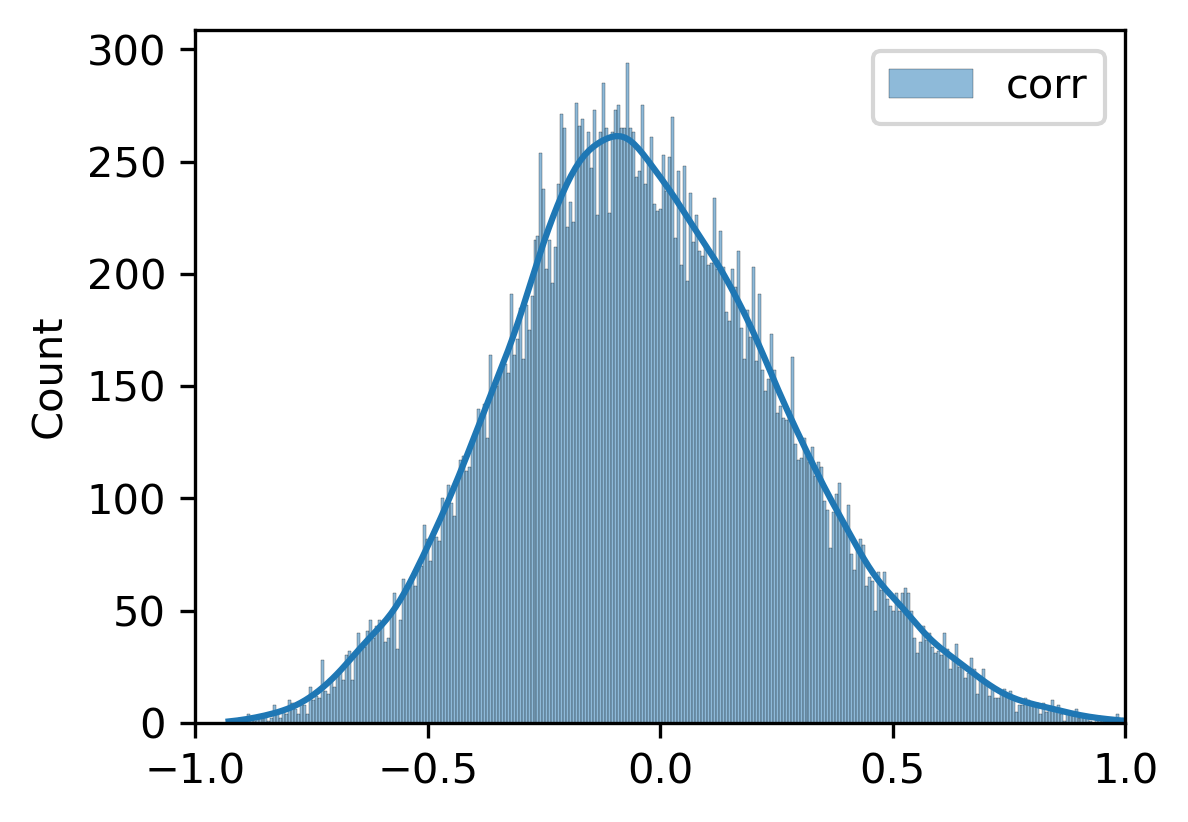

In [92]:
fig, ax = plt.subplots(figsize = (4,3), dpi = 300)
sns.histplot(corr_values, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(corr_df_diagonal_values_2, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(s_corr_df_diagonal_values,ax = ax, kde=True,bins=300, label = 'shuffle')

ax.set_xlim(-1,1)
# ax.axvline(x=0, color='red', linestyle='--', label='baseline')
# ax.set_xlabel(f'{mc_type} {condition} chr{chromosome}')
plt.legend()
# fig.savefig(f'/ceph/MethDev/pbio/kay/results/0413_filtered_exclude2_9_mc_rna_correlation.pdf', bbox_inches='tight')

In [93]:
thres = -0.8
(corr_values<=thres).sum()

50

In [94]:
rna_matrix = rna_matrix.T
rna_matrix

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
AT1G01010,2.377856,3.427461,0.037791,0.929936,2.313070,0.647959,1.361582,11.107595,0.917293,6.978723,10.272727,5.679487,0.980392,20.04,0.1250
AT1G01020,30.949033,56.386010,15.168605,34.477707,41.820669,17.770408,67.073446,33.322785,44.932331,6.425532,29.935065,36.628205,15.941176,96.24,19.8750
AT1G01030,9.337434,16.386010,8.904070,5.878981,8.835866,0.464286,3.627119,4.727848,10.789474,0.000000,9.077922,0.269231,25.176471,8.20,0.0625
AT1G01040,51.249561,78.549223,27.770349,39.506369,32.340426,34.061224,26.548023,32.734177,42.120301,5.542553,23.051948,50.910256,55.568627,87.16,77.6250
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG09730,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
ATMG09740,0.005272,0.002591,0.203488,0.015924,0.006079,0.071429,0.000000,0.037975,0.060150,0.000000,0.000000,0.000000,0.000000,0.08,0.0000
ATMG09950,0.000000,0.000000,0.014535,0.000000,0.000000,0.000000,0.000000,0.000000,0.090226,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
ATMG09960,0.007030,0.023316,0.008721,0.000000,0.003040,0.005102,0.000000,0.006329,0.015038,0.000000,0.000000,0.000000,0.000000,0.00,0.0000


In [95]:
mCGN_frac_by_cluster = mCGN_frac_by_cluster.T
mCGN_frac_by_cluster

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
gene,,,,,,,,,,,,,,,
AT1G01010,0.025490,0.028993,0.032244,0.034498,0.025919,0.021434,0.035757,0.026185,0.042767,0.000000,0.018553,0.032520,0.021322,0.020440,0.025000
AT1G01020,0.069221,0.057388,0.058621,0.048050,0.064257,0.056250,0.059511,0.061662,0.063752,0.041667,0.051793,0.077605,0.023585,0.036101,0.021053
AT1G03987,0.000000,0.009804,0.027027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AT1G01030,0.004898,0.006477,0.004906,0.005613,0.004799,0.002647,0.002796,0.005244,0.004905,0.000000,0.006633,0.003612,0.004425,0.003308,0.000000
AT1G01040,0.597558,0.603006,0.621651,0.614978,0.604484,0.607248,0.613012,0.648350,0.633127,0.637985,0.641171,0.535795,0.531317,0.586660,0.614035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATCG01270,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATCG01280,0.027778,0.000000,0.000000,0.000000,0.011494,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027778,0.000000,0.000000,0.000000
ATCG01290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [96]:
below_threshold = corr_values[corr_values<=thres]
thres_mc_df = mCGN_frac_by_cluster.loc[below_threshold.index]
thres_mc_df

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
AT1G07720,0.025075,0.025115,0.031406,0.006212,0.030673,0.004507,0.021400,0.018783,0.022073,0.019417,0.030336,0.023996,0.016517,0.020761,0.026005
AT1G13120,0.258559,0.252903,0.269241,0.251776,0.283358,0.265544,0.265366,0.281946,0.264817,0.368421,0.298969,0.262563,0.217610,0.242051,0.146067
AT1G16960,0.196190,0.170470,0.228814,0.195864,0.199682,0.201542,0.206511,0.226902,0.170297,0.156627,0.188498,0.171765,0.218310,0.217391,0.051282
AT1G30480,0.076634,0.082482,0.090565,0.077130,0.082255,0.095966,0.065257,0.080552,0.096154,0.098901,0.093162,0.061323,0.052854,0.085062,0.045455
AT1G49670,0.391201,0.375375,0.445664,0.389593,0.396789,0.382673,0.414243,0.410095,0.409879,0.455090,0.441836,0.365310,0.329912,0.363971,0.355505
AT1G51440,0.081990,0.074515,0.102432,0.034176,0.085184,0.016682,0.079691,0.052772,0.076796,0.067961,0.057405,0.074705,0.101818,0.084149,0.088000
AT1G62030,0.101587,0.098666,0.125833,0.021892,0.114917,0.013677,0.092800,0.078976,0.083578,0.133540,0.132900,0.079581,0.100000,0.124587,0.122715
AT1G64360,0.006294,0.004506,0.005423,0.005333,0.004657,0.005843,0.005352,0.004469,0.004601,0.006711,0.000000,0.006745,0.000000,0.006536,0.000000
AT1G64530,0.342544,0.338587,0.356915,0.368410,0.355692,0.356535,0.355019,0.352226,0.383198,0.355882,0.368085,0.323416,0.256158,0.348684,0.359240
AT1G66100,0.768029,0.768259,0.885877,0.456943,0.849843,0.120810,0.863061,0.848617,0.848790,0.943396,0.877273,0.661734,0.614815,0.694175,0.787037


In [97]:
corr_values.loc['AT2G10940']

-0.6107126733183896

In [102]:
corr_values.loc['AT4G30400']

-0.9049458812545333

In [98]:
mCGN_frac_by_cluster.loc['AT2G10940']

cluster
0.0     0.073860
1.0     0.054819
2.0     0.172100
3.0     0.597840
4.0     0.131740
5.0     0.682808
6.0     0.140235
7.0     0.617546
8.0     0.145806
9.0     0.339869
10.0    0.556281
11.0    0.145455
12.0    0.645740
13.0    0.042796
14.0    0.413793
Name: AT2G10940, dtype: float64

In [99]:
rna_matrix.loc['AT2G10940']

cluster
0.0      93.449912
1.0     123.862694
2.0      72.049419
3.0      27.480892
4.0     120.264438
5.0      21.729592
6.0     181.327684
7.0      39.848101
8.0      35.112782
9.0      10.095745
10.0     17.961039
11.0     90.538462
12.0      4.568627
13.0     14.000000
14.0     11.437500
Name: AT2G10940, dtype: float64

In [100]:
mCGN_frac_by_cluster.loc['AT4G30400']

cluster
0.0     0.187187
1.0     0.188917
2.0     0.208333
3.0     0.038911
4.0     0.196899
5.0     0.022835
6.0     0.179267
7.0     0.123724
8.0     0.201337
9.0     0.230469
10.0    0.138144
11.0    0.154455
12.0    0.155216
13.0    0.217949
14.0    0.221519
Name: AT4G30400, dtype: float64

In [101]:
rna_matrix.loc['AT4G30400']

cluster
0.0      1.499121
1.0      0.181347
2.0      0.031977
3.0     52.337580
4.0      0.015198
5.0     77.571429
6.0      2.214689
7.0     18.759494
8.0      0.022556
9.0      1.053191
10.0     3.974026
11.0     0.064103
12.0     0.000000
13.0     0.000000
14.0     0.000000
Name: AT4G30400, dtype: float64

In [103]:
df_zscore = thres_mc_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
df_zscore

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
AT1G07720,0.454731,0.459763,1.256627,-1.934505,1.163730,-2.150489,-0.010799,-0.342282,0.074481,-0.261868,1.121089,0.318003,-0.629313,-0.091662,0.572494
AT1G13120,-0.073620,-0.196548,0.158557,-0.221038,0.465353,0.078192,0.074332,0.434673,0.062388,2.314106,0.804652,0.013406,-0.963587,-0.432387,-2.518479
AT1G16960,0.219564,-0.374007,0.972425,0.212040,0.300135,0.343060,0.457729,0.928315,-0.377994,-0.693476,0.042049,-0.344123,0.730025,0.708827,-3.124569
AT1G30480,-0.140557,0.219476,0.717131,-0.109977,0.205526,1.049649,-0.840991,0.100696,1.061218,1.230356,0.876994,-1.083161,-1.604575,0.378352,-2.060137
AT1G49670,-0.111745,-0.560456,1.432448,-0.157349,0.046702,-0.353540,0.541559,0.423947,0.417824,1.699706,1.323907,-0.845839,-1.849488,-0.883818,-1.123857
AT1G51440,0.431504,0.112315,1.304404,-1.610223,0.567903,-2.357278,0.333314,-0.816175,0.209686,-0.167558,-0.618311,0.120419,1.278191,0.523677,0.688132
AT1G62030,0.180340,0.100156,0.845858,-2.007135,0.546214,-2.232618,-0.060842,-0.440277,-0.313958,1.057401,1.039814,-0.423673,0.136784,0.811661,0.760277
AT1G64360,0.769204,0.030628,0.409476,0.372448,0.093284,0.582958,0.380307,0.015613,0.070106,0.941560,-1.830088,0.955582,-1.830088,0.869098,-1.830088
AT1G64530,-0.190211,-0.327191,0.307210,0.705135,0.264896,0.294083,0.241606,0.144908,1.217013,0.271480,0.693879,-0.852338,-3.180497,0.022316,0.387708
AT1G66100,0.168094,0.169187,0.726875,-1.306924,0.556016,-2.900704,0.618691,0.550205,0.551026,0.999602,0.686076,-0.335906,-0.558372,-0.182086,0.258222


In [104]:
#drop 2 and 9
# df_zscore = df_zscore.drop(columns=[2.0,9.0], axis = 0)

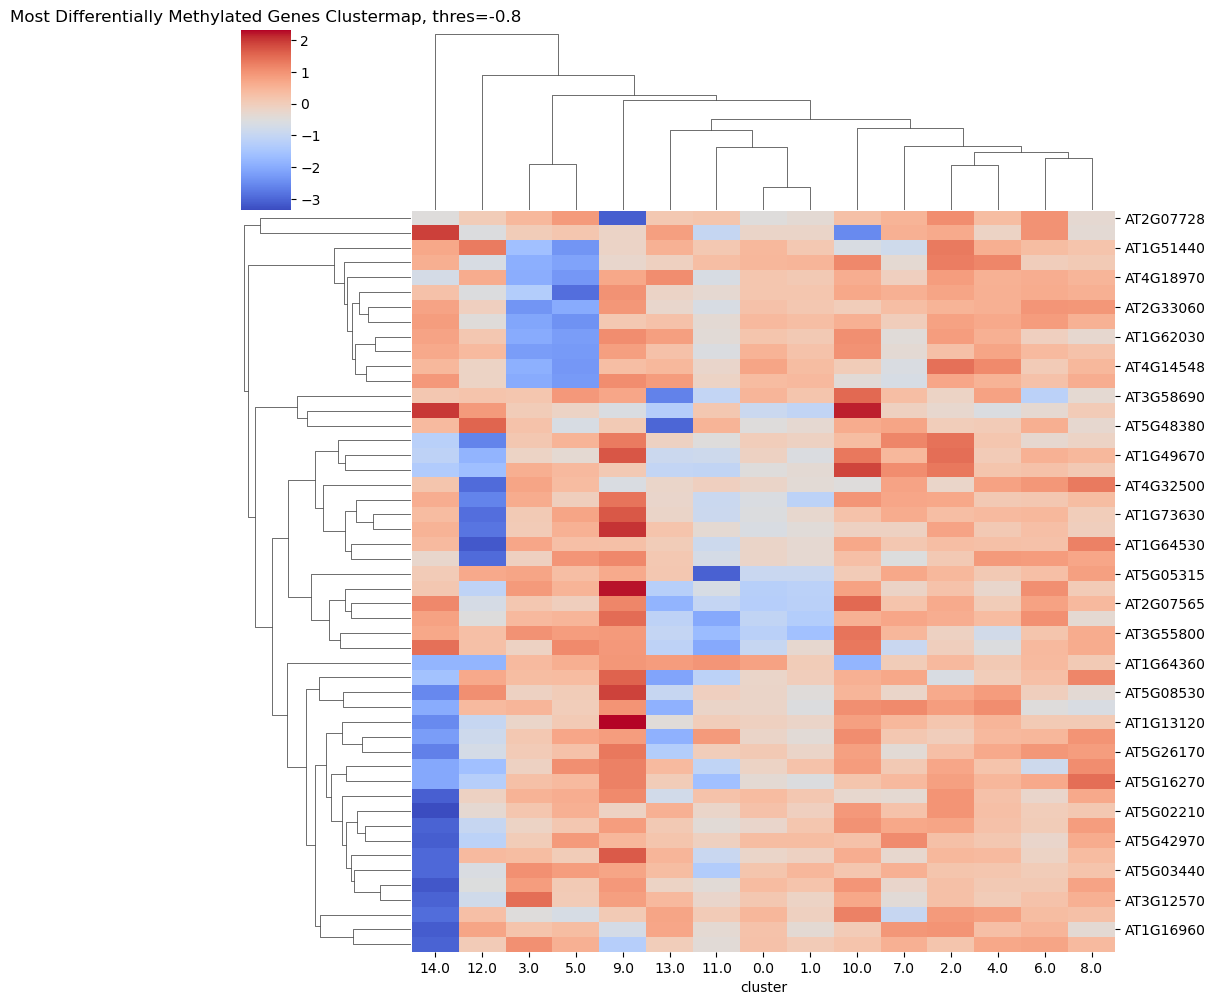

In [105]:
cluster = sns.clustermap(df_zscore, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

plt.title(f'Most Differentially Methylated Genes Clustermap, thres={thres}')
# plt.savefig('/ceph/MethDev/pbio/kay/result/highMCClusterMap.pdf')
plt.show()

In [106]:
gene_order = cluster.dendrogram_row.reordered_ind
seurat_order = cluster.dendrogram_col.reordered_ind
thres_rna_df = rna_matrix.loc[below_threshold.index]#.drop(columns=[2.0,9.0], axis = 0)
thres_rna_df_reordered = thres_rna_df.iloc[gene_order,seurat_order]

In [107]:
# meth_aligned_rna_df = filtered_rna_df.iloc[gene_order,seurat_order]
# meth_aligned_rna_df
# thres_rna_df_reordered = thres_rna_df_reordered.drop(columns=[2.0,9.0], axis = 0)
thres_rna_df_reordered

cluster,14.0,12.0,3.0,5.0,9.0,13.0,11.0,0.0,1.0,10.0,7.0,2.0,4.0,6.0,8.0
AT2G07728,0.0000,0.000000,0.019108,0.005102,0.957447,0.00,0.000000,0.086116,0.082902,0.000000,0.139241,0.014535,0.015198,0.062147,0.000000
AT4G13430,0.3125,14.078431,8.073248,2.540816,0.659574,0.12,16.679487,4.210896,6.266839,63.636364,2.056962,3.244186,3.273556,8.864407,14.962406
AT1G51440,9.6250,8.784314,88.165605,279.464286,0.000000,0.00,16.897436,3.166960,4.476684,24.597403,51.816456,2.043605,3.662614,3.689266,1.872180
AT1G07720,0.0625,0.019608,80.894904,131.877551,0.489362,0.56,2.474359,2.998243,6.054404,2.129870,23.253165,0.043605,1.191489,8.785311,0.015038
AT4G18970,0.6250,0.039216,12.366242,41.622449,0.000000,0.00,14.461538,0.521968,0.642487,0.441558,0.006329,0.171512,0.197568,0.559322,0.969925
AT1G66100,15.3125,5.862745,11.891720,65.826531,3.170213,6.64,10.217949,10.049209,13.005181,8.415584,8.677215,6.482558,7.258359,5.672316,9.308271
AT2G33060,0.0625,0.000000,38.149682,33.882653,0.000000,0.00,3.102564,0.149385,1.948187,5.194805,1.221519,0.575581,0.297872,1.598870,0.090226
AT3G23450,0.5000,0.274510,12.105096,29.622449,0.074468,1.88,8.115385,0.887522,2.243523,0.831169,9.677215,0.587209,0.762918,1.559322,0.112782
AT1G62030,0.0000,1.588235,33.178344,37.612245,0.000000,0.00,3.615385,0.126538,0.137306,1.441558,3.018987,0.029070,0.015198,1.649718,0.060150
AT2G28630,0.0000,0.117647,6.168790,18.295918,0.000000,0.20,1.641026,0.156415,0.150259,0.000000,0.088608,0.061047,0.085106,0.112994,0.203008


In [108]:
rna_zscore = thres_rna_df_reordered.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
# rna_zscore

<AxesSubplot:xlabel='cluster'>

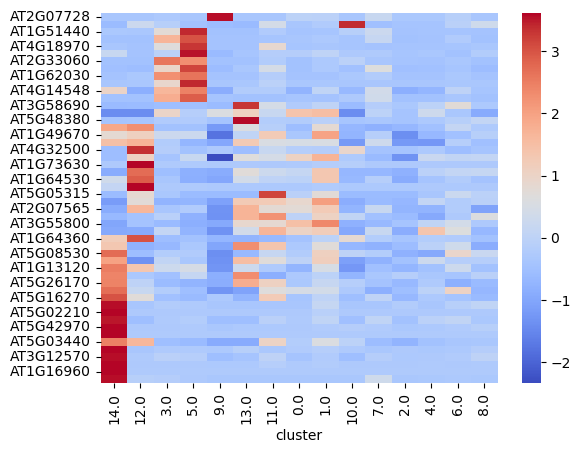

In [109]:
sns.heatmap(rna_zscore,cmap = 'coolwarm')